In [17]:
# To inspect the dataset with tools
import pandas as pd
import numpy as np

# Load the data
df_train = pd.read_csv('dataset_train.csv')
headers = df_train.columns.tolist()

# Basic exploration
print("Shape:", df_train.shape)
print("\nFirst few rows:")
print(df_train.head())
print("\nColumn names:")
print(headers)

Shape: (1600, 19)

First few rows:
   Index Hogwarts House First Name  Last Name    Birthday Best Hand  \
0      0      Ravenclaw     Tamara        Hsu  2000-03-30      Left   
1      1      Slytherin      Erich    Paredes  1999-10-14     Right   
2      2      Ravenclaw   Stephany      Braun  1999-11-03      Left   
3      3     Gryffindor      Vesta  Mcmichael  2000-08-19      Left   
4      4     Gryffindor     Gaston      Gibbs  1998-09-27      Left   

   Arithmancy   Astronomy  Herbology  Defense Against the Dark Arts  \
0     58384.0 -487.886086   5.727180                       4.878861   
1     67239.0 -552.060507  -5.987446                       5.520605   
2     23702.0 -366.076117   7.725017                       3.660761   
3     32667.0  697.742809  -6.497214                      -6.977428   
4     60158.0  436.775204  -7.820623                            NaN   

   Divination  Muggle Studies  Ancient Runes  History of Magic  \
0       4.722      272.035831     532.484226 

In [43]:
# No pandas' build-in functions outside of reading the file
import math

def calculate_count(series):
    return len(series.dropna())

def calculate_mean(series):
    clean_data = series.dropna()
    return sum(clean_data) / len(clean_data) if len(clean_data) > 0 else None

def calculate_std(series):
    mean = calculate_mean(series)
    clean_data = series.dropna()
    sum = 0
    count = 0
    for value in clean_data:
        sum += (value - mean) ** 2
        count += 1
    return math.sqrt(sum/(count - 1)) if count > 1 else None

def calculate_min(series):
    clean_data = series.dropna()
    if len(clean_data) == 0:
        return None
    min_val = clean_data.iloc[0]
    for value in clean_data:
        if value < min_val:
            min_val = value
    return min_val

def calculate_max(series):
    clean_data = series.dropna()
    if len(clean_data) == 0:
        return None
    max_val = clean_data.iloc[0]
    for value in clean_data:
        if value > max_val:
            max_val = value
    return max_val

def calculate_percentile(series, percentile):
    """
    Calculate percentile (0-1, e.g., 0.25 for 25th percentile)
    """
    clean_data = series.dropna().sort_values().reset_index(drop=True)
    count = len(clean_data)
    if count == 0:
        return None
    
    position = percentile * (count - 1)
    lower_index = int(position)
    upper_index = lower_index + 1
    
    if upper_index >= count:
        return clean_data.iloc[lower_index]
    
    # Interpolate
    weight = position - lower_index
    return clean_data.iloc[lower_index] * (1 - weight) + clean_data.iloc[upper_index] * weight


# Get only numerical columns (course scores)
numerical_cols = df_train.select_dtypes(include=[np.number]).columns

def print_describe_table(stats):
    # Get all column names
    columns = list(stats.keys())
    stat_names = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
    stat_keys = ["count", "mean", "std", "min", "p25", "p50", "p75", "max"]
    
    # Print header (column names)
    print(f"{'':>10} " + " ".join(f"{col:>15}" for col in columns))
    print("-" * (10 + 15 * len(columns)))
    
    # Print each statistic as a row
    for stat_name, stat_key in zip(stat_names, stat_keys):
        values = [stats[col][stat_key] for col in columns]
        print(f"{stat_name:>10} " + " ".join(f"{v:>15.6f}" for v in values))

stats = {}
for col in numerical_cols:
    stats[col] = {
        "count" : calculate_count(df_train[col]),
        "mean" : calculate_mean(df_train[col]),
        "min" : calculate_min(df_train[col]),
        "max" : calculate_max(df_train[col]),
        "std" : calculate_std(df_train[col]),
        "p25" : calculate_percentile(df_train[col], 0.25),
        "p50" : calculate_percentile(df_train[col], 0.5),
        "p75" : calculate_percentile(df_train[col], 0.75)
    }

print_describe_table(stats)

test_data = pd.Series([10, 20, 30, 40, 50])
print(f"Min: {calculate_min(test_data)}")  # Should be 10
print(f"Max: {calculate_max(test_data)}")  # Should be 50
print(f"25%: {calculate_percentile(test_data, 0.25)}")  # Should be 20
print(f"50%: {calculate_percentile(test_data, 0.50)}")  # Should be 30
print(f"75%: {calculate_percentile(test_data, 0.75)}")  # Should be 40


                     Index      Arithmancy       Astronomy       Herbology Defense Against the Dark Arts      Divination  Muggle Studies   Ancient Runes History of Magic Transfiguration         Potions Care of Magical Creatures          Charms          Flying
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
     Count     1600.000000     1566.000000     1568.000000     1567.000000     1569.000000     1561.000000     1565.000000     1565.000000     1557.000000     1566.000000     1570.000000     1560.000000     1600.000000     1600.000000
      Mean      799.500000    49634.570243       39.797131        1.141020       -0.387863        3.153910     -224.589915      495.747970        2.963095     1030.096946        5.950373       -0.053427     -243.374409       21.958012
       Std      462.024530    16679.806036      5

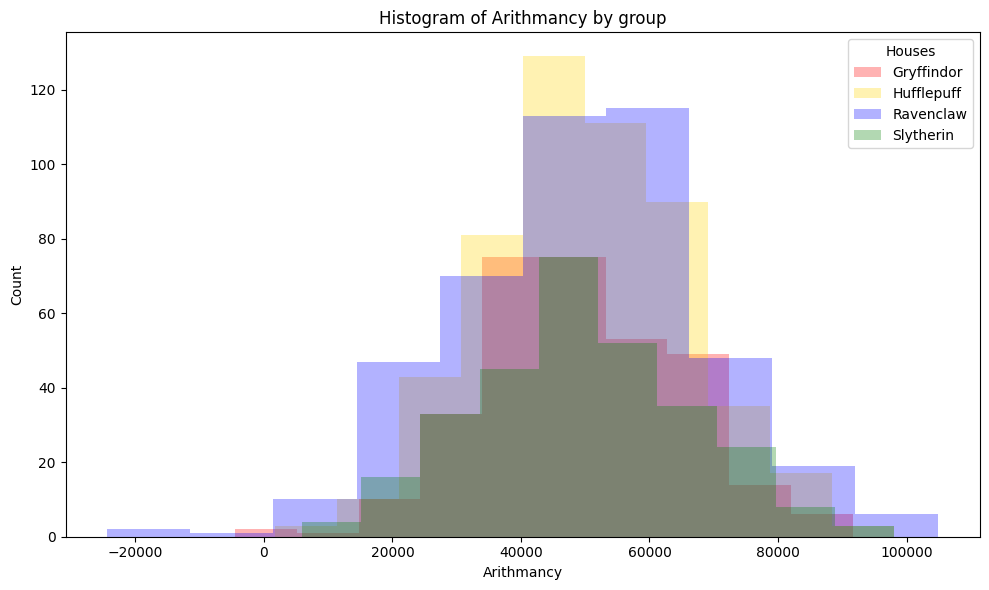

In [ ]:
import matplotlib.pyplot as plt

course_columns = [
    'Arithmancy', 'Astronomy', 'Herbology', 
    'Defense Against the Dark Arts', 'Divination',
    'Muggle Studies', 'Ancient Runes', 'History of Magic',
    'Transfiguration', 'Potions', 'Care of Magical Creatures',
    'Charms', 'Flying'
]

def plot_histogram(df, course_name):
    colors = {
        "Gryffindor": "red",
        "Ravenclaw": "blue",
        "Slytherin": "green",
        "Hufflepuff": "gold"
    }
    plt.figure(figsize=(10, 6))
    for house, group_df in df.groupby("Hogwarts House"):
        plt.hist(
            group_df[course_name],
            bins=10,
            alpha=0.3,
            label=house,
            color=colors.get(house, None)
        )

    plt.title(f"Histogram of {course_name} by group")
    plt.xlabel(course_name)
    plt.ylabel("Count")
    plt.legend(title="Houses")
    plt.tight_layout()
    plt.show()

plot_histogram(df_train, 'Arithmancy')

In [6]:
# Check test dataset
import pandas as pd

# Load the data
df_test = pd.read_csv('dataset_test.csv')
print("Shape:", df_test.shape)
df_test.columns[df_test.isna().any()].tolist()

Shape: (400, 19)


['Hogwarts House',
 'Arithmancy',
 'Astronomy',
 'Herbology',
 'Defense Against the Dark Arts',
 'Divination',
 'Muggle Studies',
 'Ancient Runes',
 'History of Magic',
 'Transfiguration',
 'Potions',
 'Care of Magical Creatures']